# Deteksi Dini Risiko Diabetes Berbasis Gaya Hidup
## Menggunakan Pendekatan Machine Learning
### *CDC Diabetes Health Indicators Dataset*

### BAGIAN 1: DATA INSPECTION & EDA
CELL 1 — Install Library

In [1]:
!pip install ucimlrepo
!pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 104.9 MB/s eta 0:00:00


CELL 2 — Import & Load Dataset

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

df = pd.concat([X, y], axis=1)

display(cdc_diabetes_health_indicators.variables)

print("Sample of features (X):")
print(X.head())
print("\nSample of targets (y):")
print(y.head())

df.describe()

,name,role,type,demographic,description,units,missing_values
0,ID,ID,Integer,None,Patient ID,None,no
1,Diabetes_binary,Target,Binary,None,0 = no diabetes 1 = prediabetes or diabetes,None,no
2,HighBP,Feature,Binary,None,0 = no high BP 1 = high BP,None,no
3,HighChol,Feature,Binary,None,0 = no high cholesterol 1 = high cholesterol,None,no
4,CholCheck,Feature,Binary,None,0 = no cholesterol check in 5 years 1 = yes ch...,None,no
5,BMI,Feature,Integer,None,Body Mass Index,None,no
6,Smoker,Feature,Binary,None,Have you smoked at least 100 cigarettes in you...,None,no
7,Stroke,Feature,Binary,None,(Ever told) you had a stroke. 0 = no 1 = yes,None,no
8,HeartDiseaseorAttack,Feature,Binary,None,coronary heart disease (CHD) or myocardial inf...,None,no
9,PhysActivity,Feature,Binary,None,physical activity in past 30 days - not includ...,None,no


Sample of features (X):
   HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  HeartDiseaseorAttack  \
0       1         1          1   40       1       0                     0   
1       0         0          0   25       1       0                     0   
2       1         1          1   28       0       0                     0   
3       1         0          1   27       0       0                     0   
4       1         1          1   24       0       0                     0   

   PhysActivity  Fruits  Veggies  ...  AnyHealthcare  NoDocbcCost  GenHlth  \
0             0       0        1  ...              1            0        5   
1             1       0        0  ...              0            1        3   
2             0       1        0  ...              1            1        5   
3             1       1        1  ...              1            0        2   
4             1       1        1  ...              1            0        2   

   MentHlth  PhysHlth  DiffWalk  Sex  Age  E

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,...,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875,0.139333
std,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,...,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148,0.346294
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000,0.000000
50%,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000,0.000000
75%,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000,0.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,1.000000


CELL 3 — Distribusi Target


Distribusi Kelas Target (%):
Diabetes_binary
0    86.066698
1    13.933302
Name: proportion, dtype: float64


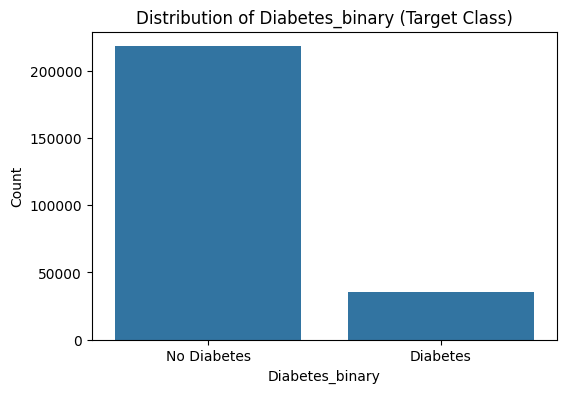

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nDistribusi Kelas Target (%):")
print(df['Diabetes_binary'].value_counts(normalize=True)*100)

plt.figure(figsize=(6, 4))
sns.countplot(x=y['Diabetes_binary'])
plt.title('Distribution of Diabetes_binary (Target Class)')
plt.xlabel('Diabetes_binary')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No Diabetes', 'Diabetes'])
plt.show()

CELL 4 — Data Cleaning

In [4]:
missing_values = df.isnull().sum()
print("Missing Values:")
print(missing_values)

df = df.drop_duplicates()
print("Number of rows after removing duplicates:", len(df))

Missing Values:
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64
Number of rows after removing duplicates: 229474


CELL 5 — Boxplot Outlier Check

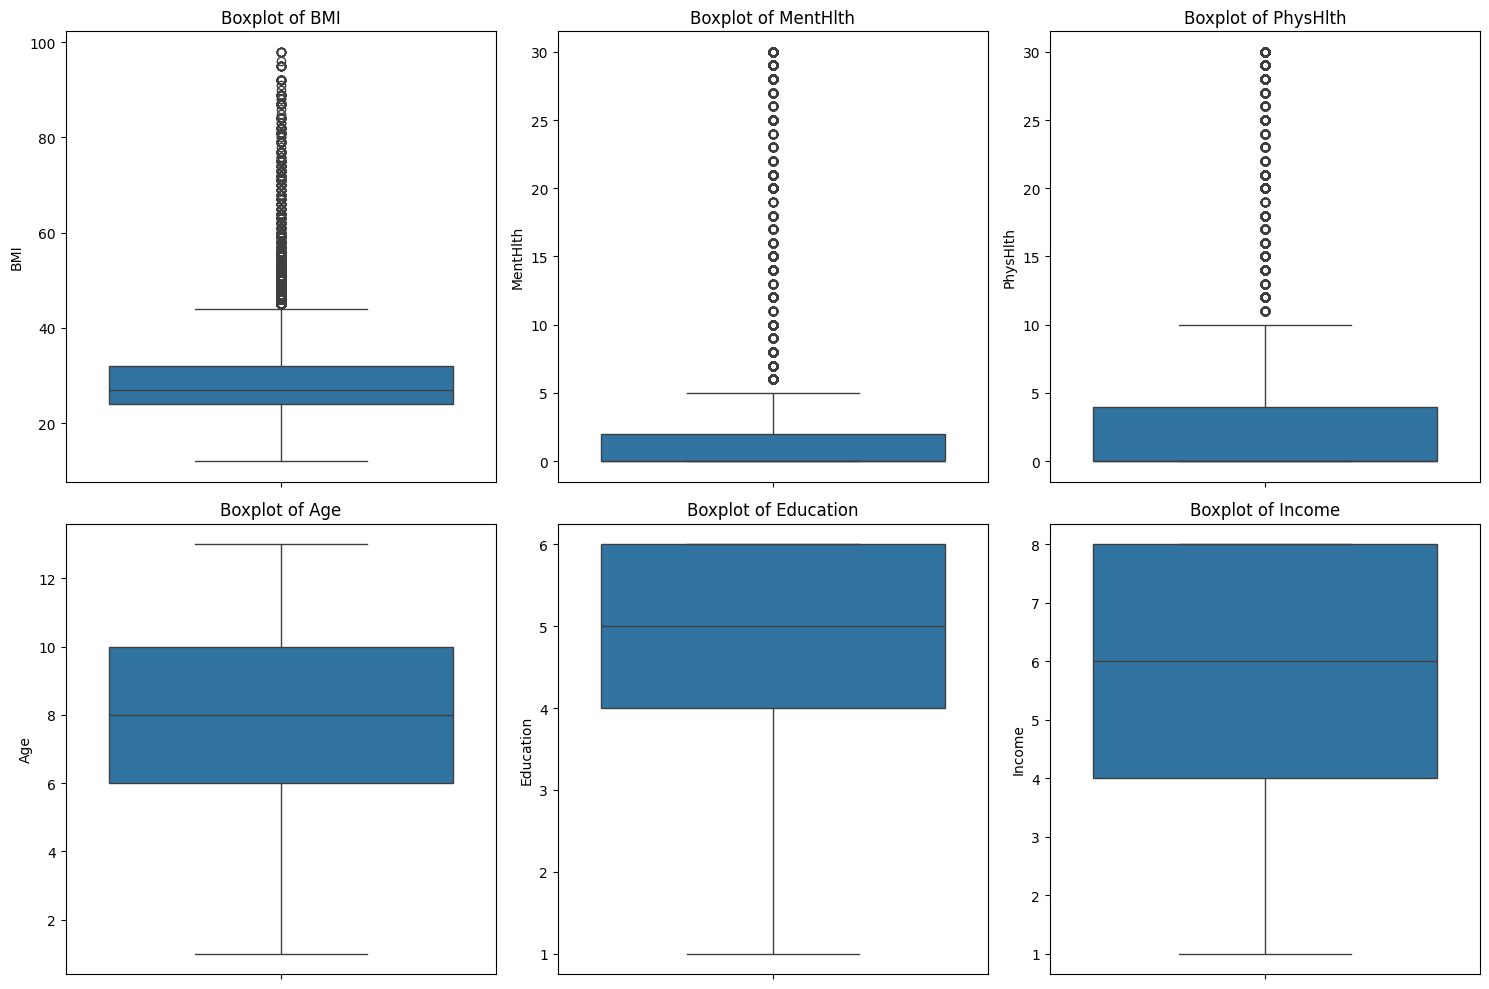

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

CELL 6 — EDA Univariate: Histogram & Boxplot Numerik

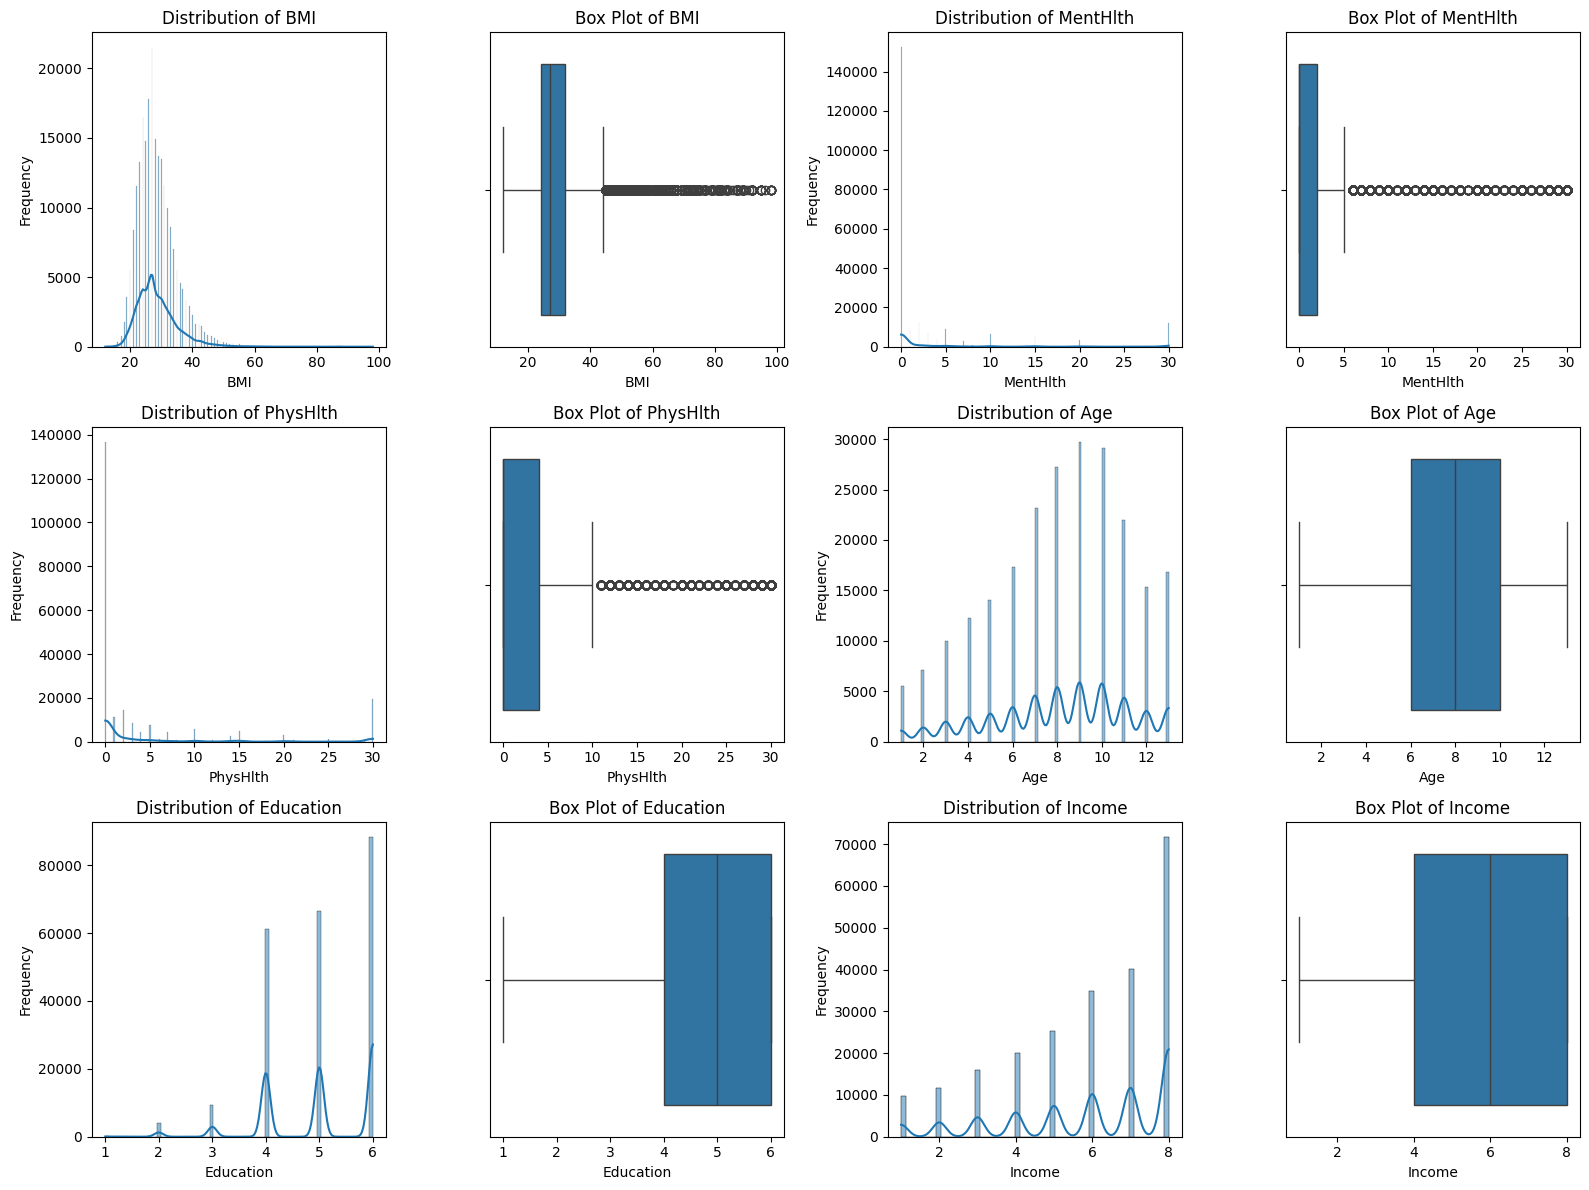

In [6]:
numerical_cols = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

n_cols = 4
n_rows = (len(numerical_cols) * 2 + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i*2])
    axes[i*2].set_title(f'Distribution of {col}')
    axes[i*2].set_xlabel(col)
    axes[i*2].set_ylabel('Frequency')

    sns.boxplot(data=df, x=col, ax=axes[i*2+1])
    axes[i*2+1].set_title(f'Box Plot of {col}')
    axes[i*2+1].set_xlabel(col)

for j in range(len(numerical_cols) * 2, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

CELL 7 — EDA Univariate: Count Plot Kategorik

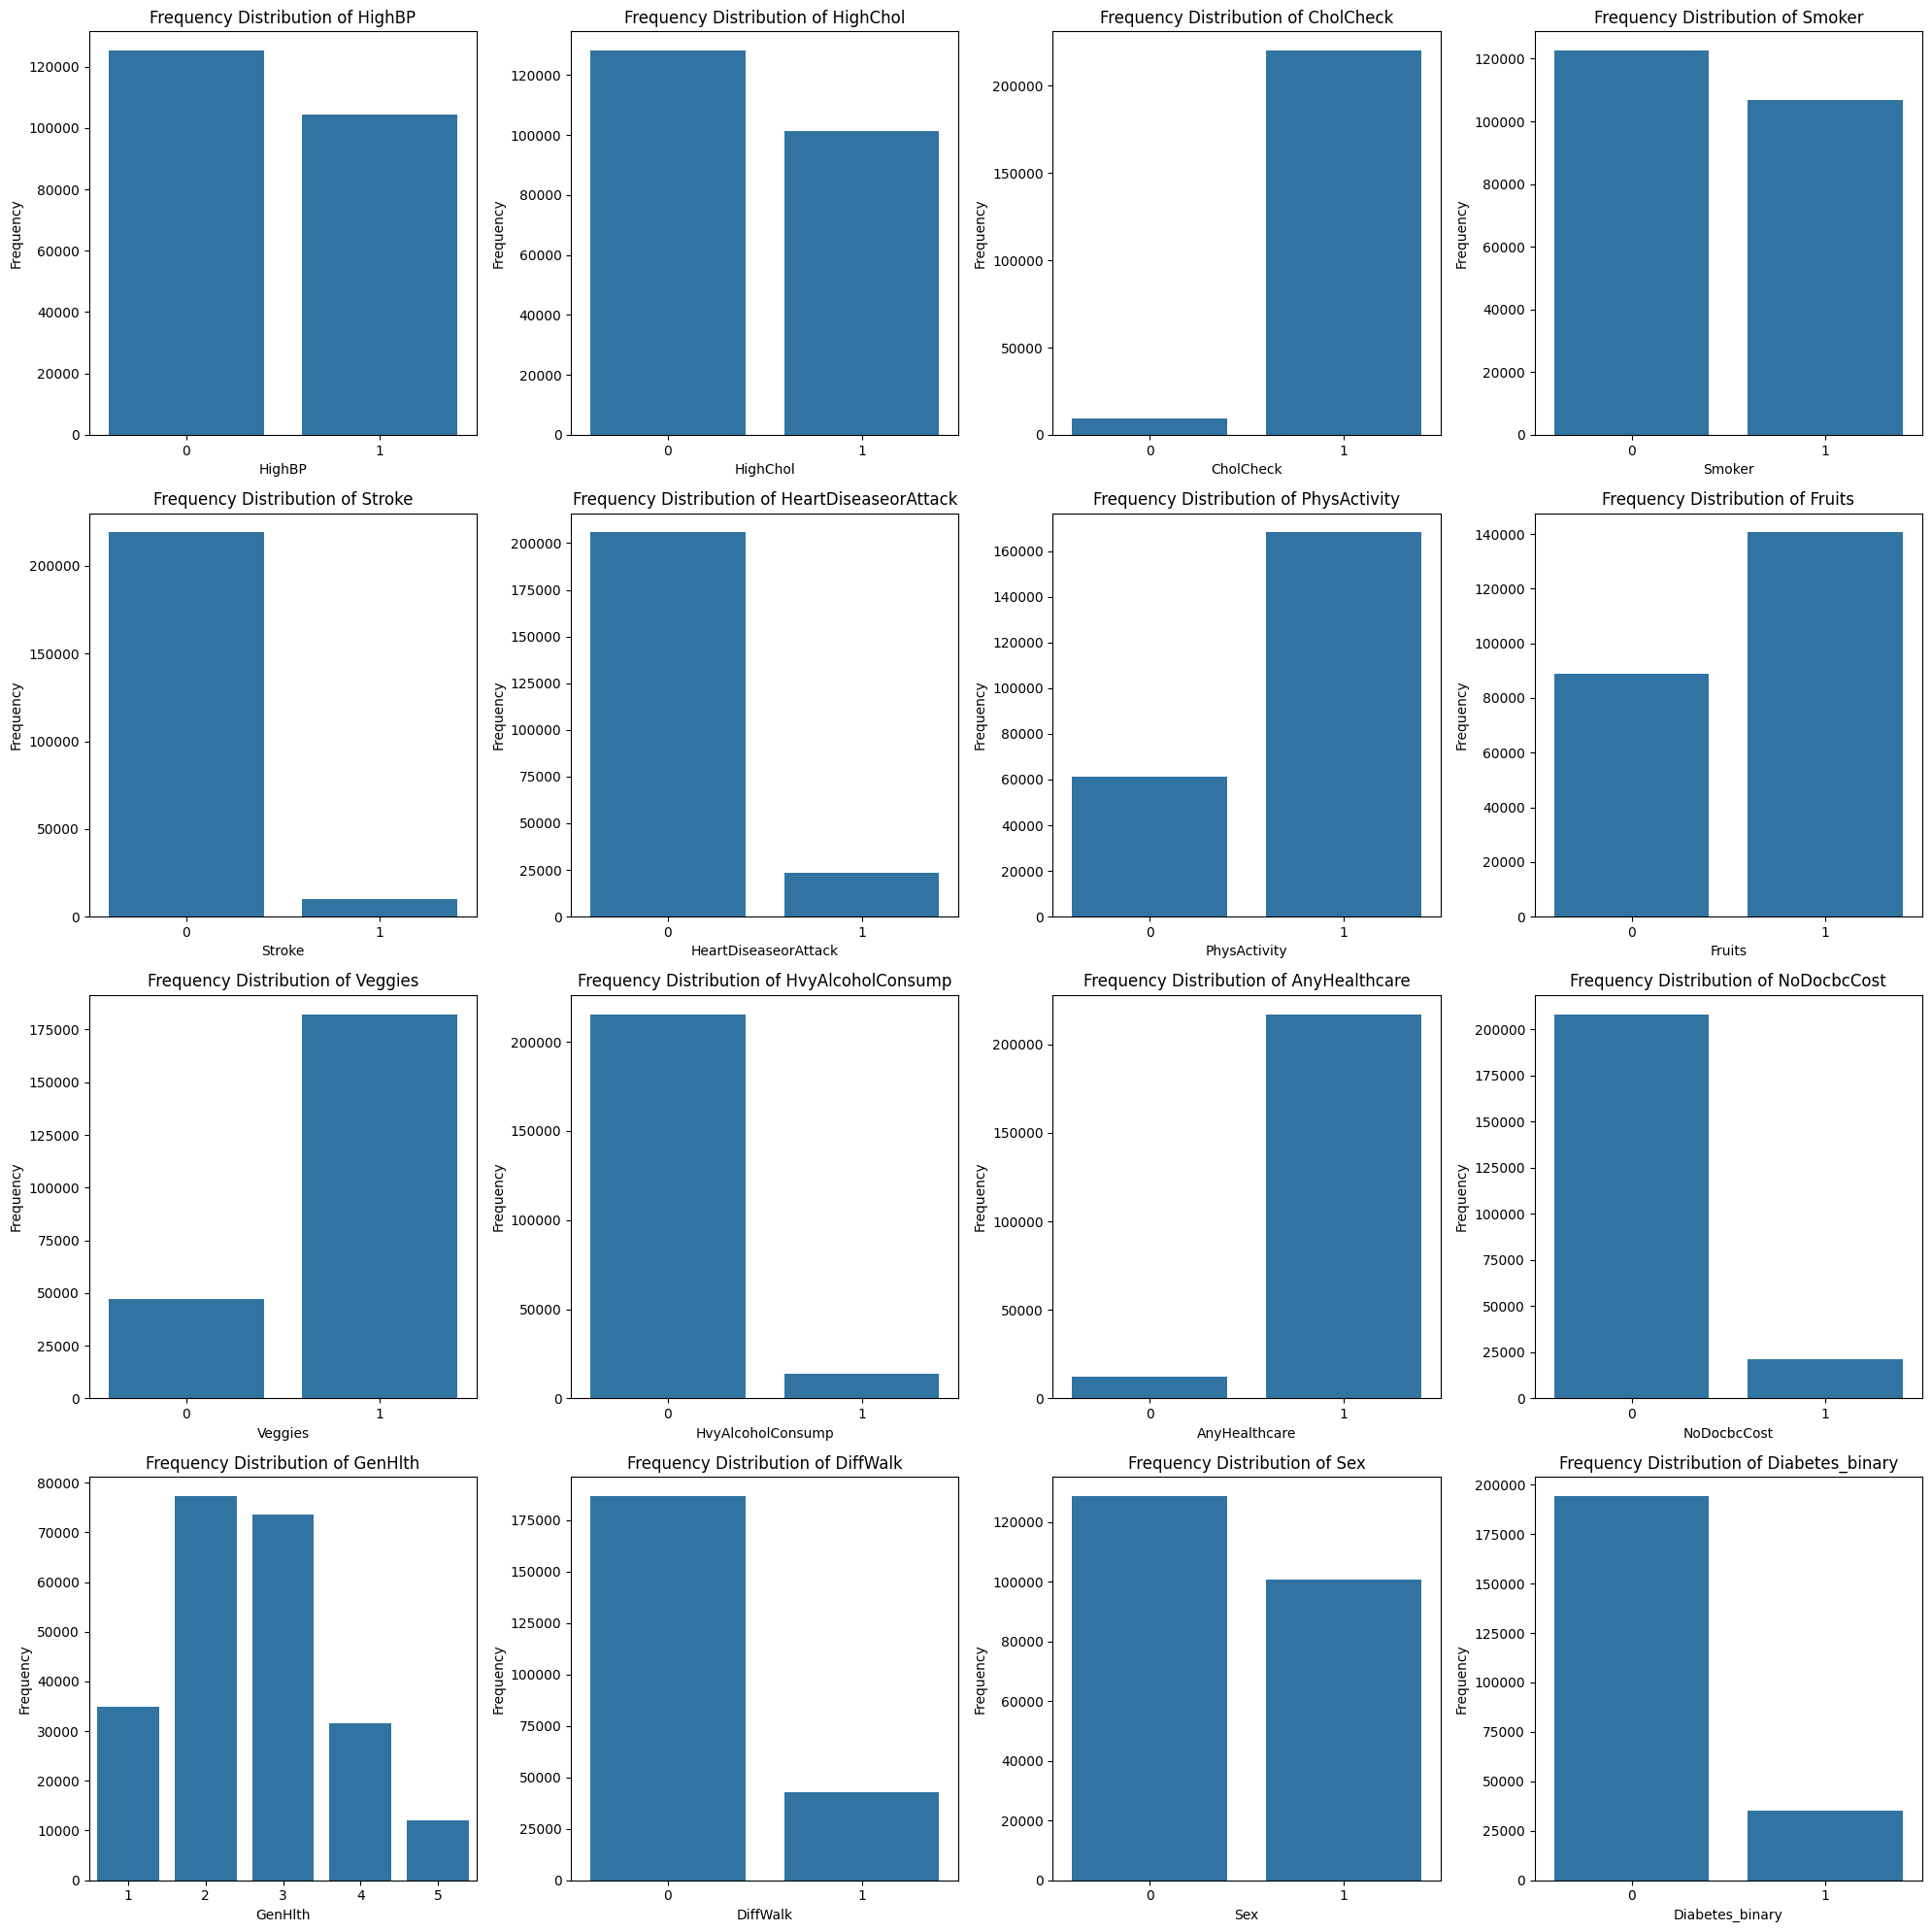

In [7]:
categorical_cols = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
                    'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
                    'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex', 'Diabetes_binary']

fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Frequency Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

CELL 8 — EDA Bivariate: Boxplot Numerik vs Target

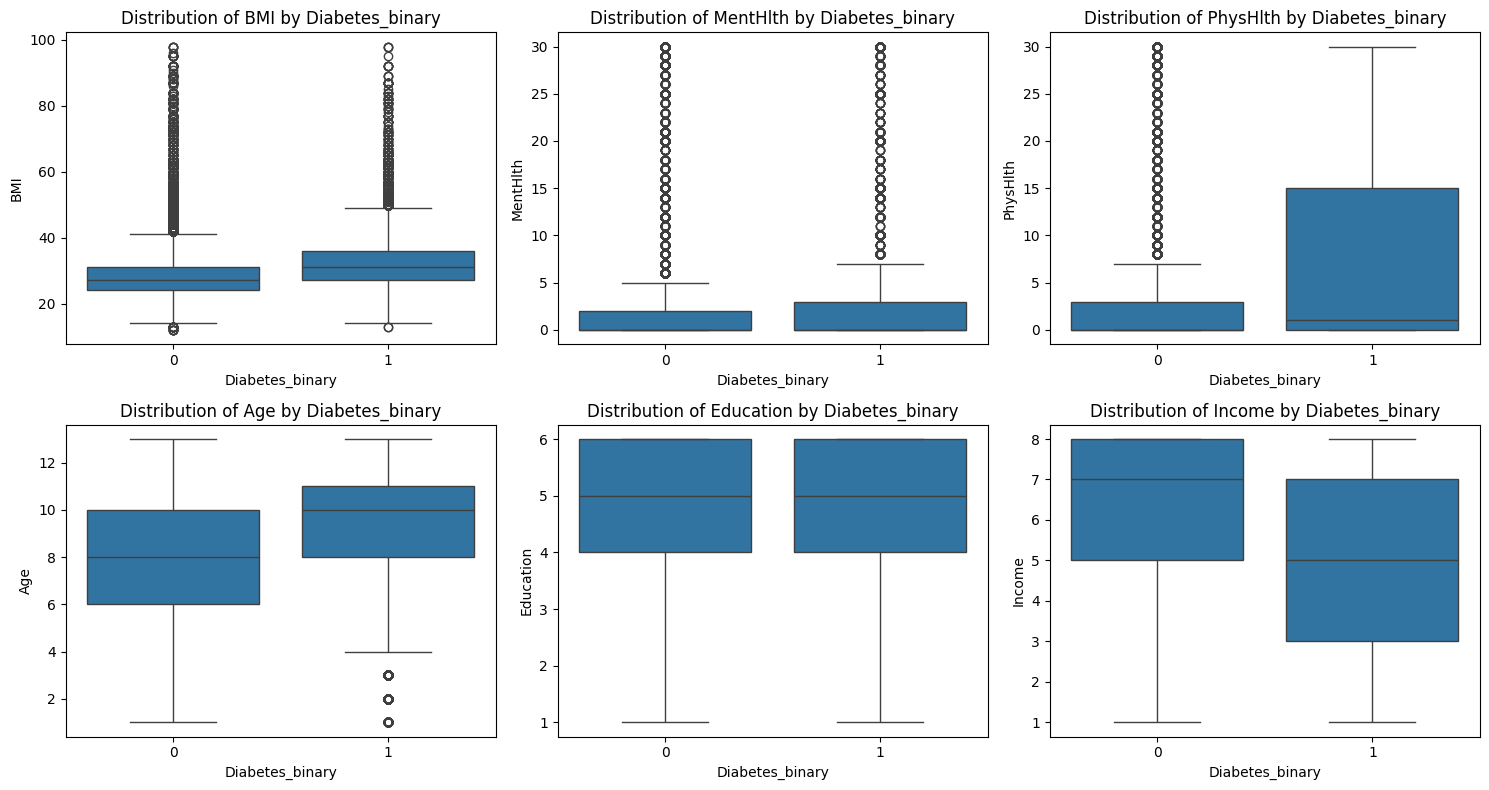

In [8]:
numerical_cols = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='Diabetes_binary', y=col, ax=axes[i])
    axes[i].set_title(f'Distribution of {col} by Diabetes_binary')
    axes[i].set_xlabel('Diabetes_binary')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

*Berdasarkan analisis boxplot, BMI dan PhysHlth menunjukkan perbedaan distribusi yang cukup jelas antara kelompok diabetes dan non-diabetes, sehingga keduanya berpotensi menjadi variabel prediktor yang baik dalam klasifikasi diabetes.*

CELL 9 — EDA Bivariate: Stacked Bar Chart Kategorik vs Target

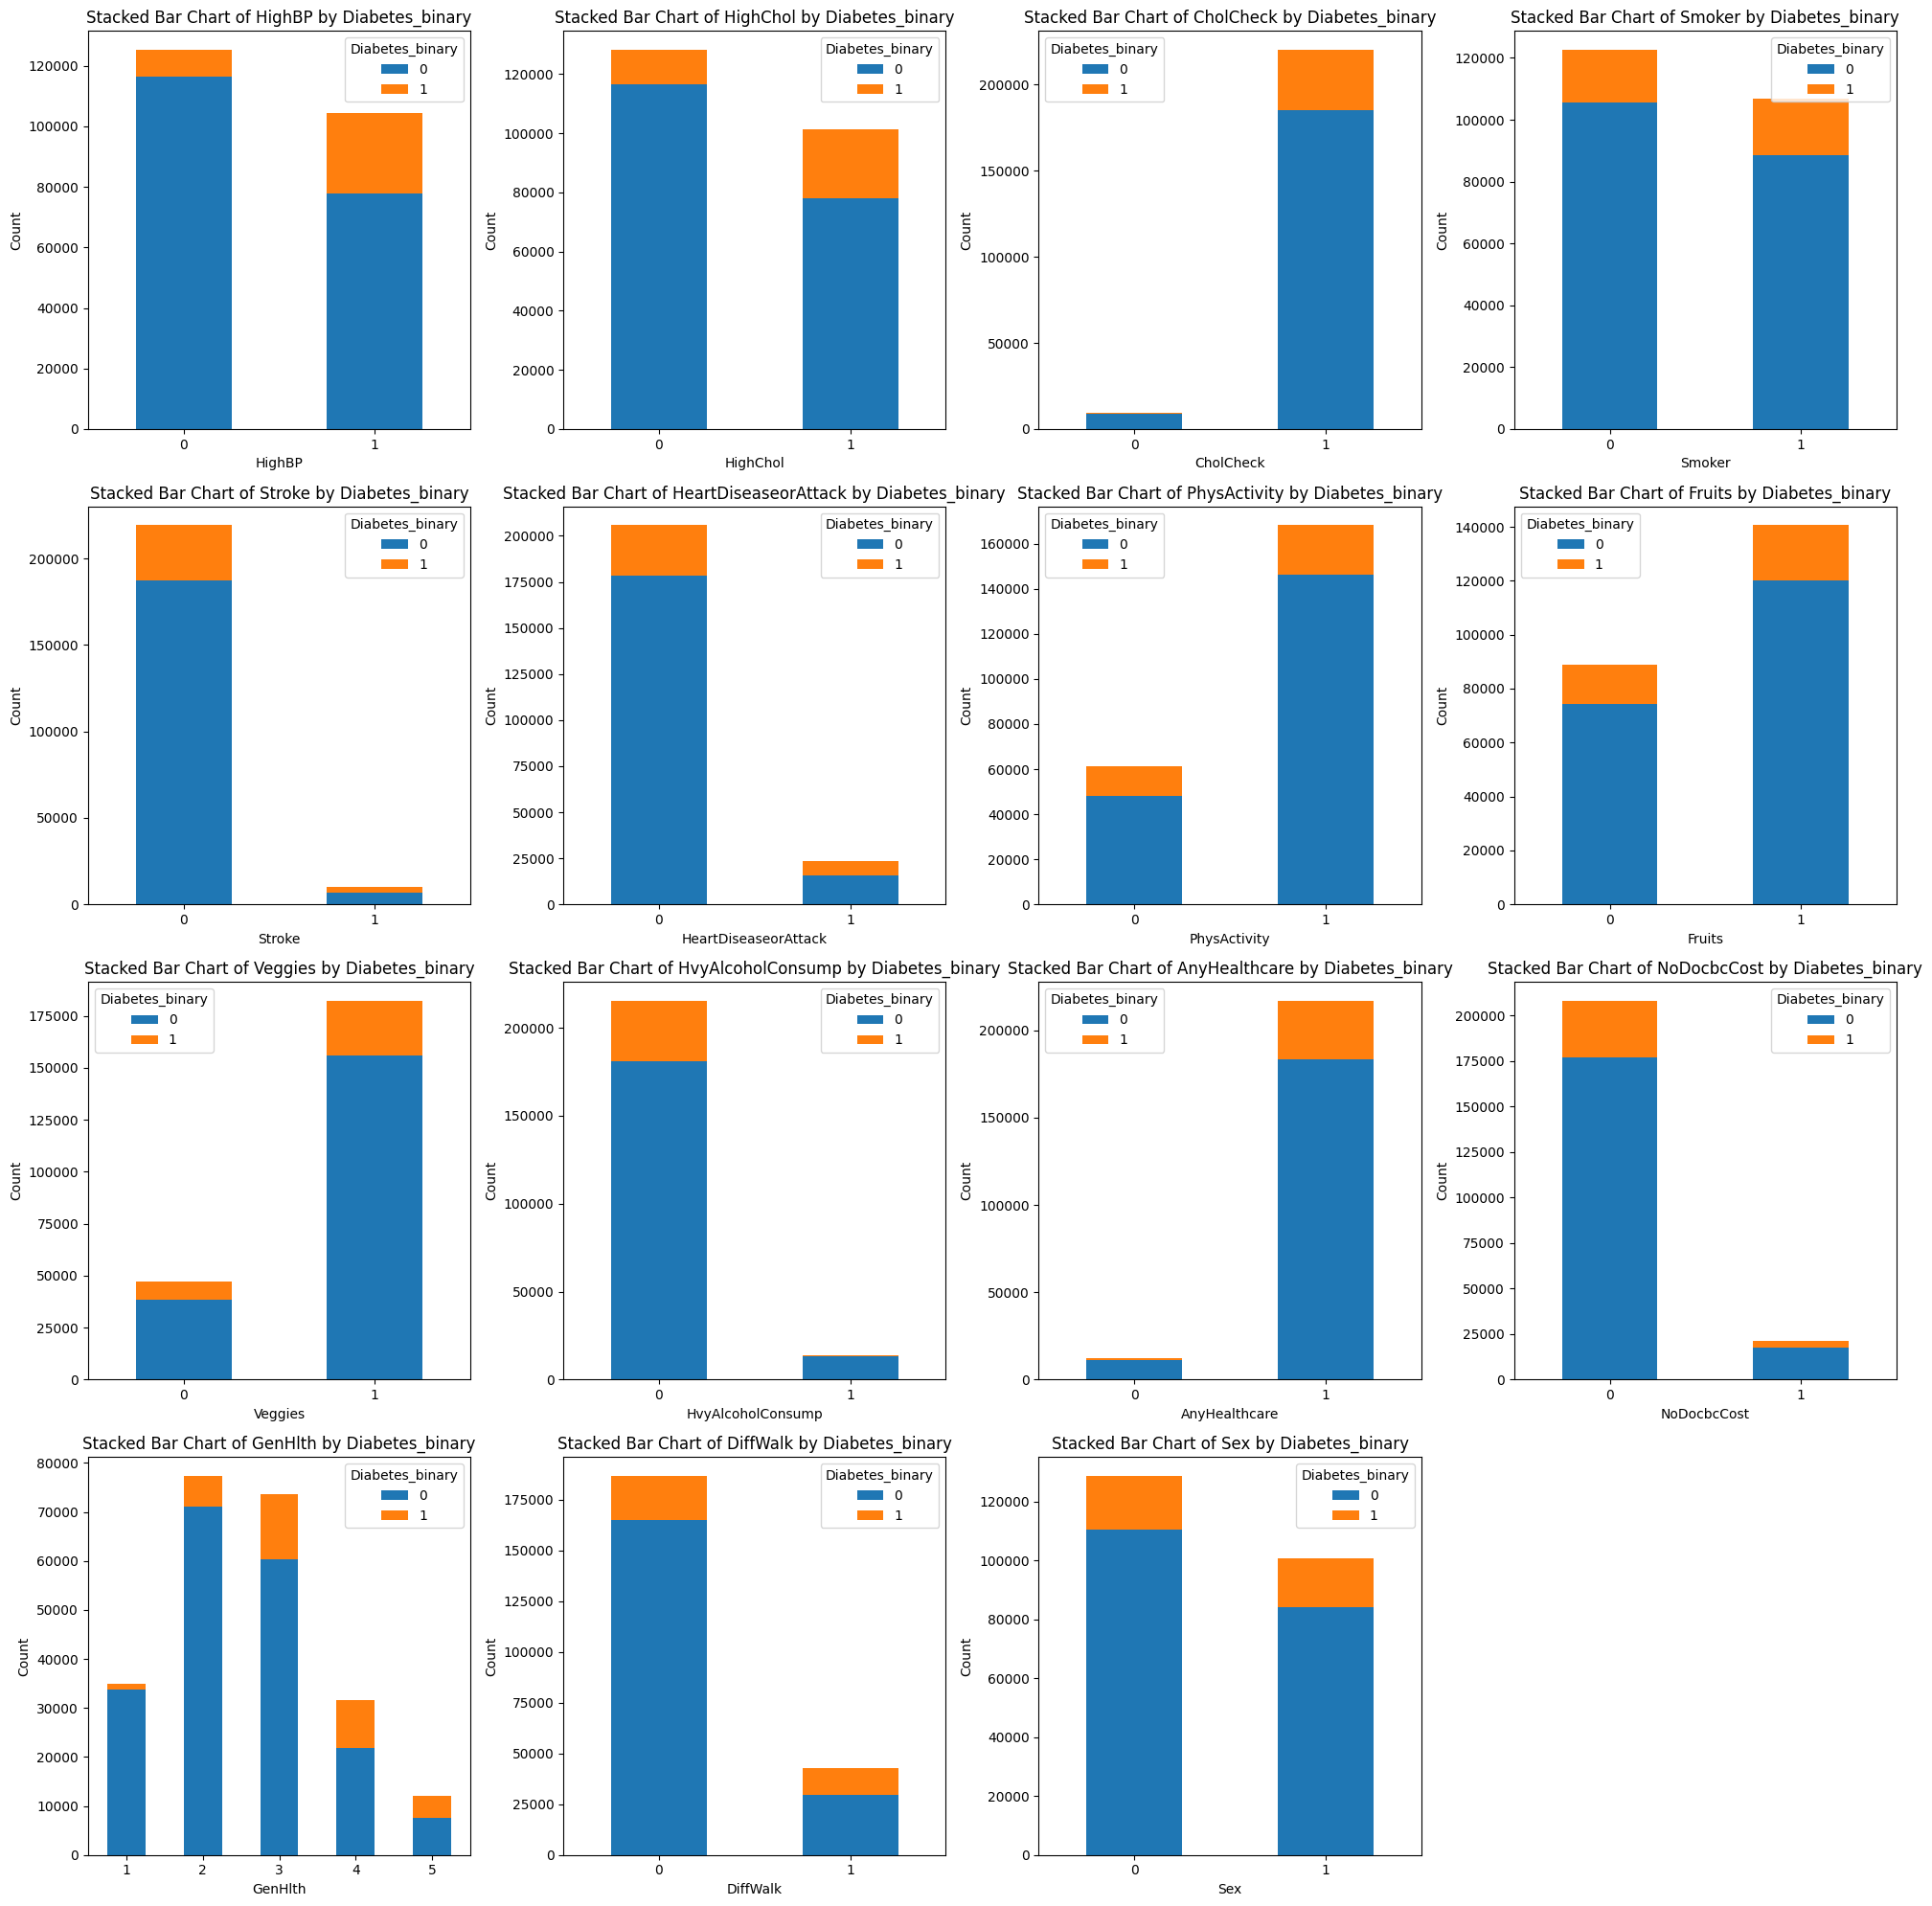

In [9]:
categorical_cols = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
                    'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
                    'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex']

fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    crosstab = pd.crosstab(df[col], df['Diabetes_binary'])
    crosstab.plot(kind='bar', stacked=True, ax=axes[i])
    axes[i].set_title(f'Stacked Bar Chart of {col} by Diabetes_binary')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=0)

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

*Berdasarkan analisis stacked bar chart, variabel HighBP, HighChol, CholCheck, PhysActivity, dan AnyHealthcare menunjukkan adanya asosiasi dengan variabel Diabetes_binary.*

CELL 10 — EDA Multivariate: Pair Plot

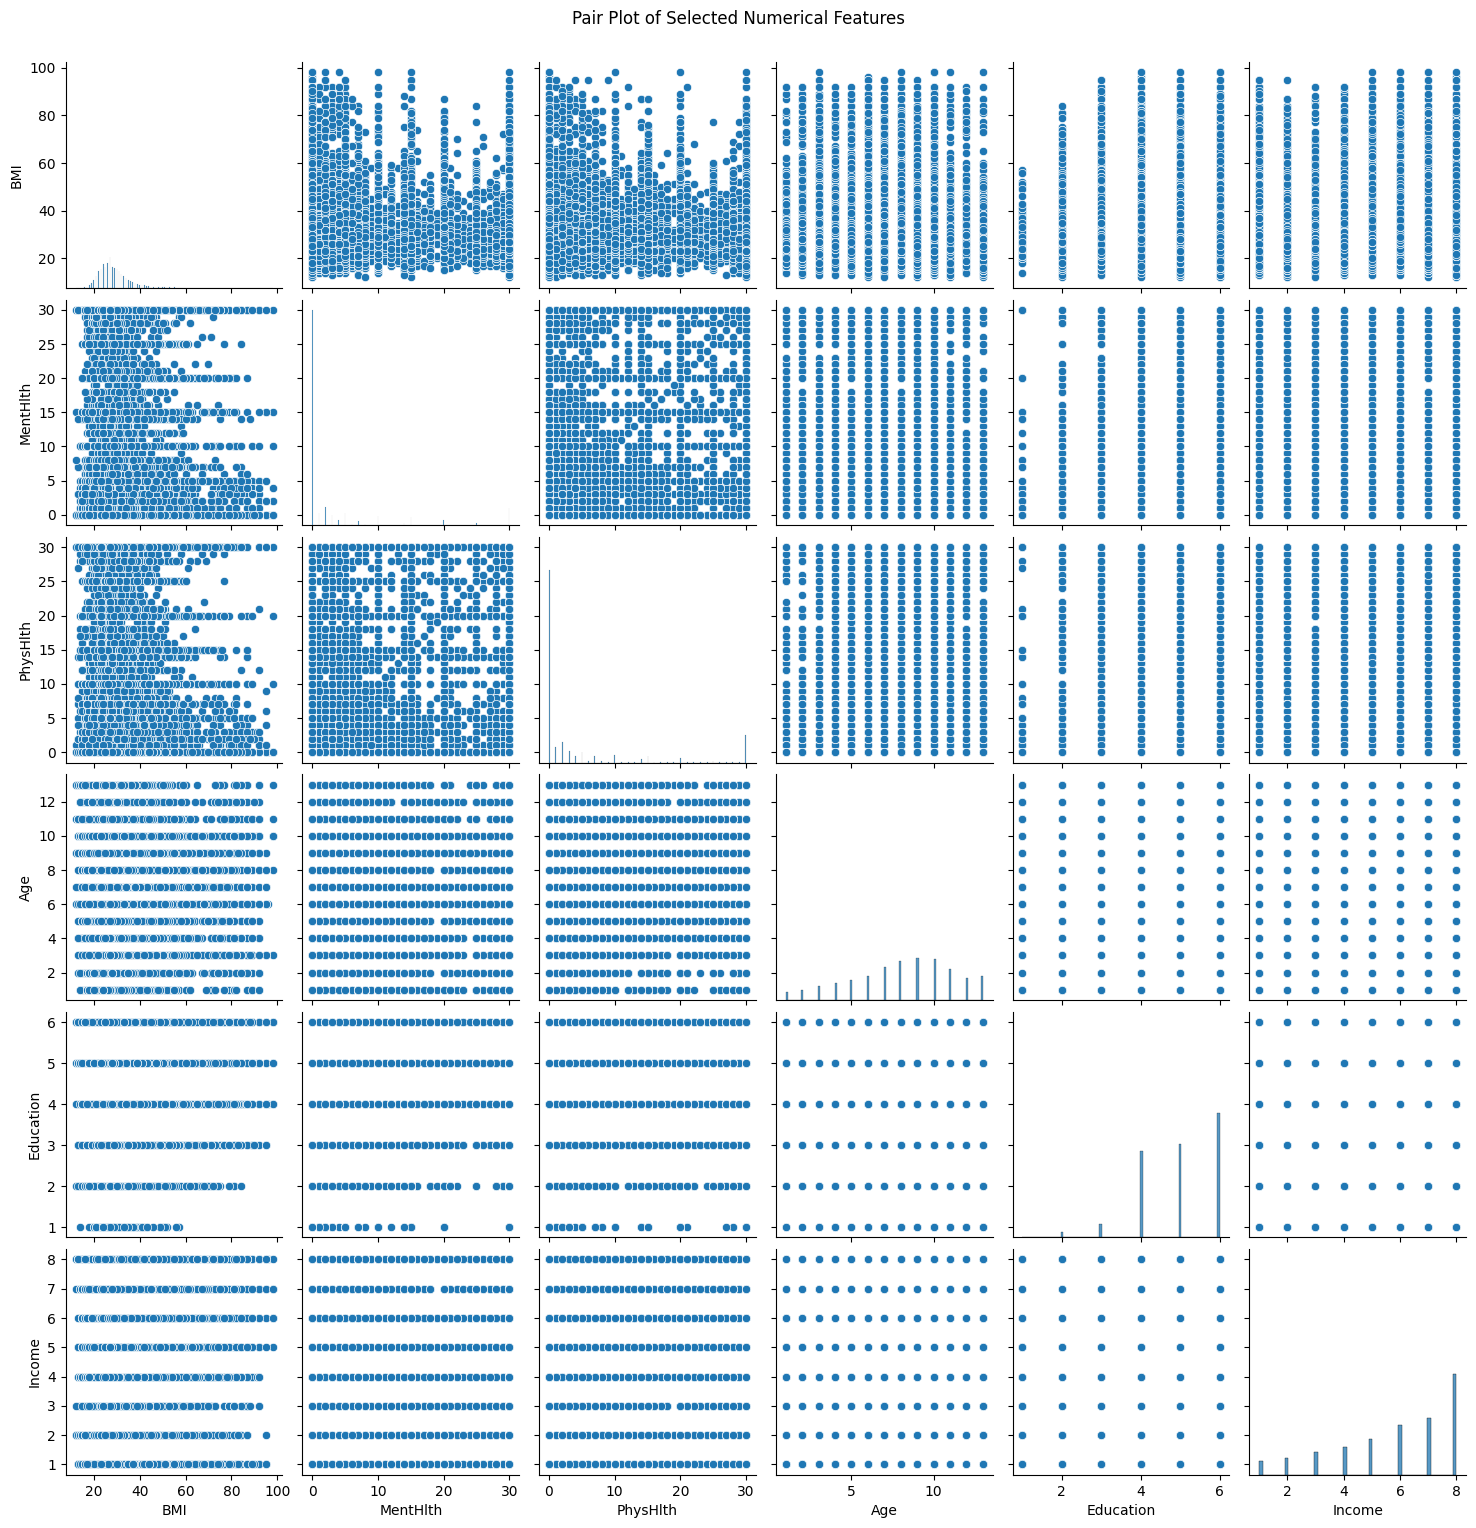

In [10]:
subset_numerical_cols = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
sns.pairplot(df[subset_numerical_cols])
plt.suptitle('Pair Plot of Selected Numerical Features', y=1.02)
plt.show()

*Berdasarkan analisis pair plot, tidak terdapat hubungan linear yang kuat antar fitur numerik. Titik-titik data tersebar secara acak dan tidak membentuk pola garis yang jelas.*

CELL 11 — Correlation Heatmap

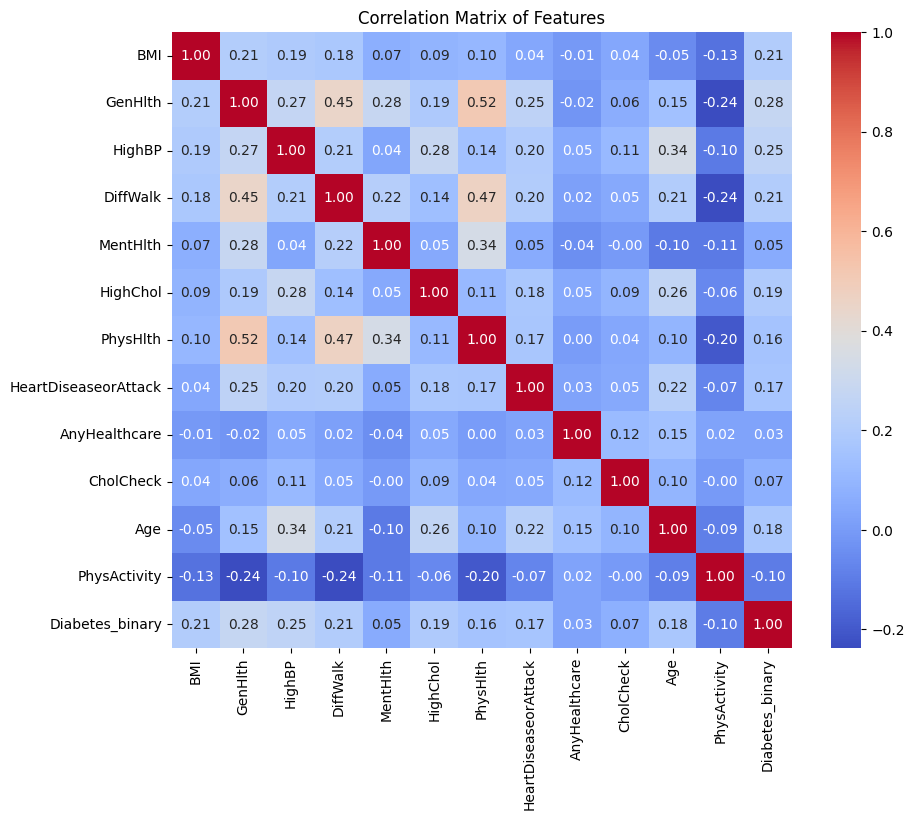

In [11]:
numerical_cols = ['BMI','GenHlth','HighBP','DiffWalk','MentHlth','HighChol',
                  'PhysHlth','HeartDiseaseorAttack','AnyHealthcare','CholCheck',
                  'Age','PhysActivity','Diabetes_binary']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

*Berdasarkan correlation heatmap, variabel GenHlth, HighBP, BMI, DiffWalk, HighChol, Age, dan PhysHlth menunjukkan hubungan positif yang cukup besar dengan target Diabetes_binary.*

CELL 12 — Correlation dengan Target

Correlation with Diabetes_binary:
Diabetes_binary         1.000000
GenHlth                 0.276940
HighBP                  0.254318
DiffWalk                0.205302
BMI                     0.205086
HighChol                0.194944
Age                     0.177263
HeartDiseaseorAttack    0.168213
PhysHlth                0.156211
Stroke                  0.099193
CholCheck               0.072523
MentHlth                0.054153
Smoker                  0.045504
Sex                     0.032724
AnyHealthcare           0.025331
NoDocbcCost             0.020048
Fruits                 -0.024805
Veggies                -0.041734
HvyAlcoholConsump      -0.065950
PhysActivity           -0.100404
Education              -0.102686
Income                 -0.140659
Name: Diabetes_binary, dtype: float64


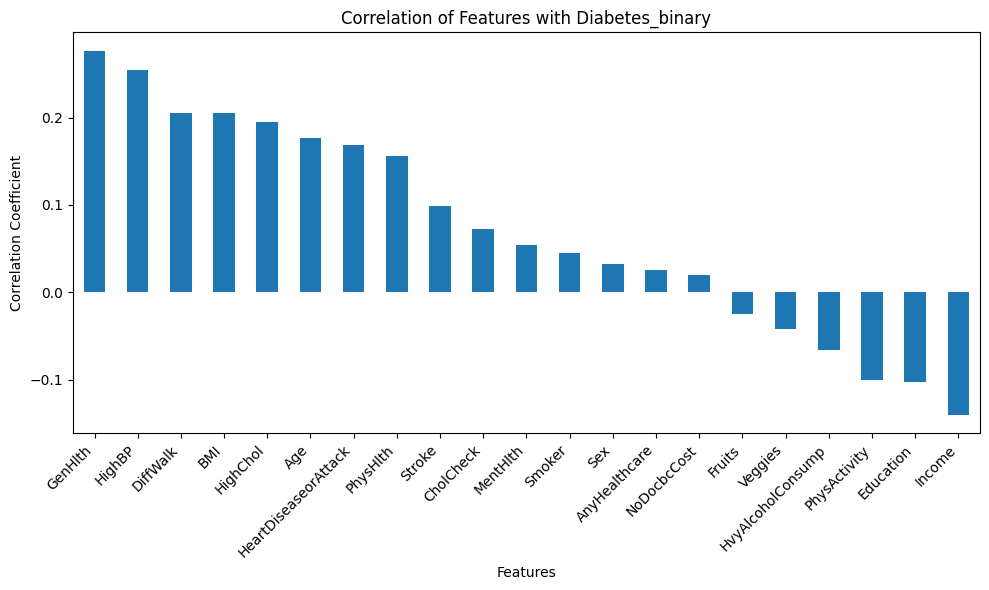

In [12]:
correlation_matrix_combined = df.corr()
correlation_with_diabetes = correlation_matrix_combined['Diabetes_binary'].sort_values(ascending=False)

print("Correlation with Diabetes_binary:")
print(correlation_with_diabetes)

plt.figure(figsize=(10, 6))
correlation_with_diabetes.drop('Diabetes_binary').plot(kind='bar')
plt.title('Correlation of Features with Diabetes_binary')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

CELL 13 — Mutual Information

Mutual Information Scores:
HighBP                  0.053140
GenHlth                 0.052544
PhysActivity            0.052416
AnyHealthcare           0.050609
CholCheck               0.048799
Fruits                  0.042253
Veggies                 0.042183
HighChol                0.040654
BMI                     0.030828
Sex                     0.025712
Smoker                  0.024667
Age                     0.023585
Education               0.023357
DiffWalk                0.022721
Income                  0.021443
HeartDiseaseorAttack    0.014241
PhysHlth                0.014222
Stroke                  0.004306
MentHlth                0.004185
HvyAlcoholConsump       0.002746
NoDocbcCost             0.000245
dtype: float64


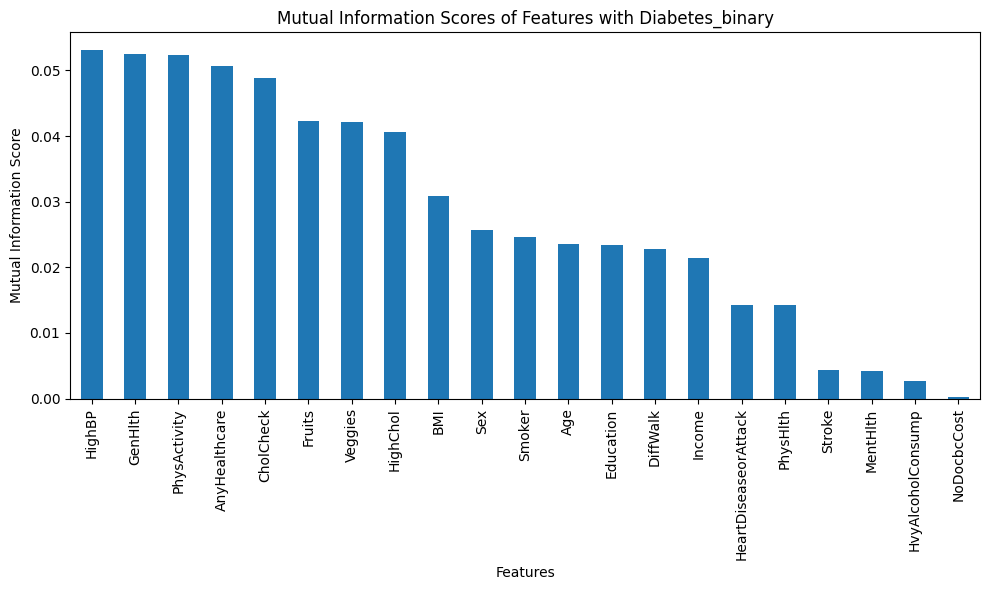

In [13]:

from sklearn.feature_selection import mutual_info_classif

mutual_info_scores = mutual_info_classif(X, y.values.ravel(), random_state=42)
mutual_info_series = pd.Series(mutual_info_scores, index=X.columns)
sorted_mutual_info = mutual_info_series.sort_values(ascending=False)

print("Mutual Information Scores:")
print(sorted_mutual_info)

plt.figure(figsize=(10, 6))
sorted_mutual_info.plot(kind='bar')
plt.title('Mutual Information Scores of Features with Diabetes_binary')
plt.xlabel('Features')
plt.ylabel('Mutual Information Score')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

CELL 14 — Principal Component Analysis (PCA)

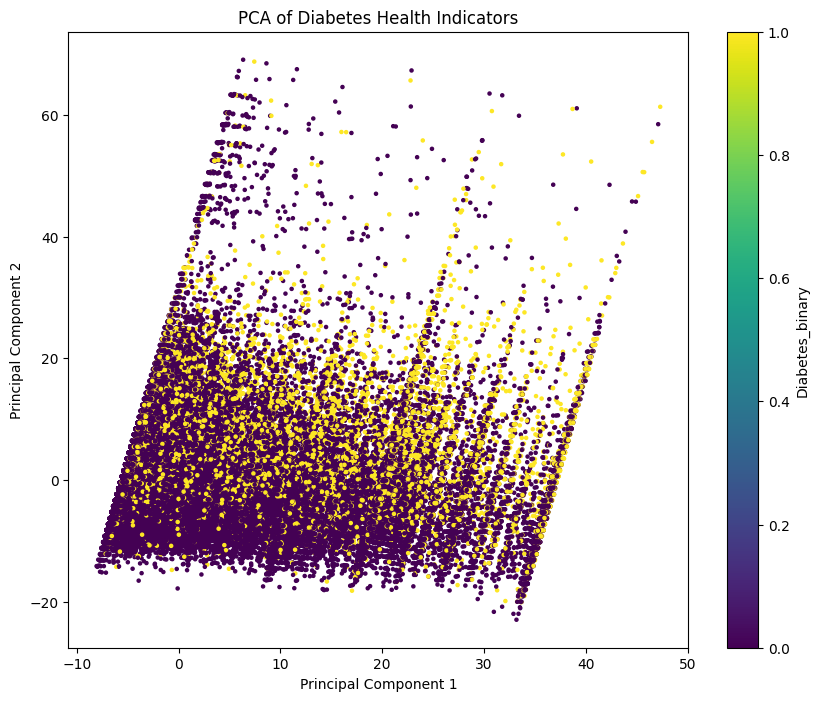

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y.values.flatten(), cmap='viridis', s=5)
plt.title('PCA of Diabetes Health Indicators')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Diabetes_binary')
plt.show()

*Berdasarkan visualisasi PCA, data diabetes dan non-diabetes masih banyak bercampur sehingga belum ada pemisahan kelas yang jelas. Oleh karena itu, dilakukan feature selection pada tahap selanjutnya.*

CELL 15 — Feature Selection

In [15]:
features_to_keep = [
    'HighBP', 'HighChol', 'CholCheck', 'BMI', 'PhysActivity', 'GenHlth',
    'Age', 'DiffWalk', 'HeartDiseaseorAttack', 'Stroke'
]

all_cols = df.columns.tolist()
cols_to_drop = [col for col in all_cols if col not in features_to_keep and col != 'Diabetes_binary']
df = df.drop(cols_to_drop, axis=1)

X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

print("Fitur terpilih:", X.columns.tolist())
print("Shape X:", X.shape)

Fitur terpilih: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'GenHlth', 'DiffWalk', 'Age']
Shape X: (229474, 10)


*Berdasarkan analisis korelasi, Mutual Information, boxplot, dan stacked bar chart, ditetapkan 10 fitur yang dipertahankan sebagai fitur prediktor untuk model: HighBP, HighChol, CholCheck, BMI, PhysActivity, GenHlth, Age, DiffWalk, HeartDiseaseorAttack, dan Stroke.*

# BAGIAN 2: PENGEMBANGAN BASE MODEL
*Tahap ini mencakup pemilihan algoritma ML, pelatihan model awal, dan evaluasi metrik dasar.*

CELL 16 — Import Library Bagian 2

In [16]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("✅ Library berhasil diimport")

✅ Library berhasil diimport


CELL 17 — Train-Test Split

*Data dibagi menjadi 80% data latih dan 20% data uji. Parameter stratify=y digunakan untuk memastikan proporsi kelas tetap seimbang di kedua subset.*

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total data  : {len(X)}")
print(f"Data train  : {X_train.shape[0]}")
print(f"Data test   : {X_test.shape[0]}")
print(f"\nDistribusi kelas train:")
print(y_train.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
print(f"\nDistribusi kelas test:")
print(y_test.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Total data  : 229474
Data train  : 183579
Data test   : 45895

Distribusi kelas train:
Diabetes_binary
0    84.71%
1    15.29%
Name: proportion, dtype: object

Distribusi kelas test:
Diabetes_binary
0    84.71%
1    15.29%
Name: proportion, dtype: object


CELL 18 — Definisi Model Base

*Dipilih 3 algoritma: Logistic Regression (baseline klasik), Decision Tree (non-linear, mudah divisualisasi), dan Random Forest (ensemble method, robust terhadap imbalanced data). Seluruh model menggunakan pengaturan default tanpa class weight untuk melihat performa awal murni.*

In [29]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

print("✅ Model berhasil didefinisikan")
for name in models:
    print(f"   - {name}")

✅ Model berhasil didefinisikan
   - Logistic Regression
   - Decision Tree
   - Random Forest


CELL 19 — Training & Evaluasi Base Model

In [30]:
results = []
trained_models = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"  Training: {name}")
    print('='*50)

    model.fit(X_train, y_train)
    trained_models[name] = model

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec  = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1   = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    auc  = roc_auc_score(y_test, y_proba)

    results.append({
        'Model'    : name,
        'Accuracy' : round(acc,  4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec,  4),
        'F1-Score' : round(f1,   4),
        'ROC-AUC'  : round(auc,  4)
    })

    print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

print("\n✅ Semua model selesai dilatih!")


  Training: Logistic Regression
              precision    recall  f1-score   support

 No Diabetes       0.86      0.98      0.92     38876
    Diabetes       0.54      0.14      0.23      7019

    accuracy                           0.85     45895
   macro avg       0.70      0.56      0.57     45895
weighted avg       0.81      0.85      0.81     45895


  Training: Decision Tree
              precision    recall  f1-score   support

 No Diabetes       0.87      0.95      0.91     38876
    Diabetes       0.40      0.18      0.25      7019

    accuracy                           0.83     45895
   macro avg       0.63      0.57      0.58     45895
weighted avg       0.79      0.83      0.81     45895


  Training: Random Forest
              precision    recall  f1-score   support

 No Diabetes       0.87      0.95      0.91     38876
    Diabetes       0.43      0.21      0.28      7019

    accuracy                           0.84     45895
   macro avg       0.65      0.58      0.

CELL 20 — Tabel Perbandingan Base Model

In [31]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('Recall', ascending=False).reset_index(drop=True)

print("="*65)
print("       PERBANDINGAN HASIL BASE MODEL")
print("="*65)
print(df_results.to_string(index=False))
print("="*65)
print(f"\n🏆 Model terbaik berdasarkan Recall: {df_results.iloc[0]['Model']}")

       PERBANDINGAN HASIL BASE MODEL
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
      Random Forest    0.8371     0.4330  0.2111    0.2839   0.7466
      Decision Tree    0.8334     0.4016  0.1816    0.2501   0.6793
Logistic Regression    0.8504     0.5406  0.1443    0.2278   0.8059

🏆 Model terbaik berdasarkan Recall: Random Forest


CELL 21 — Visualisasi Metrik Base Model

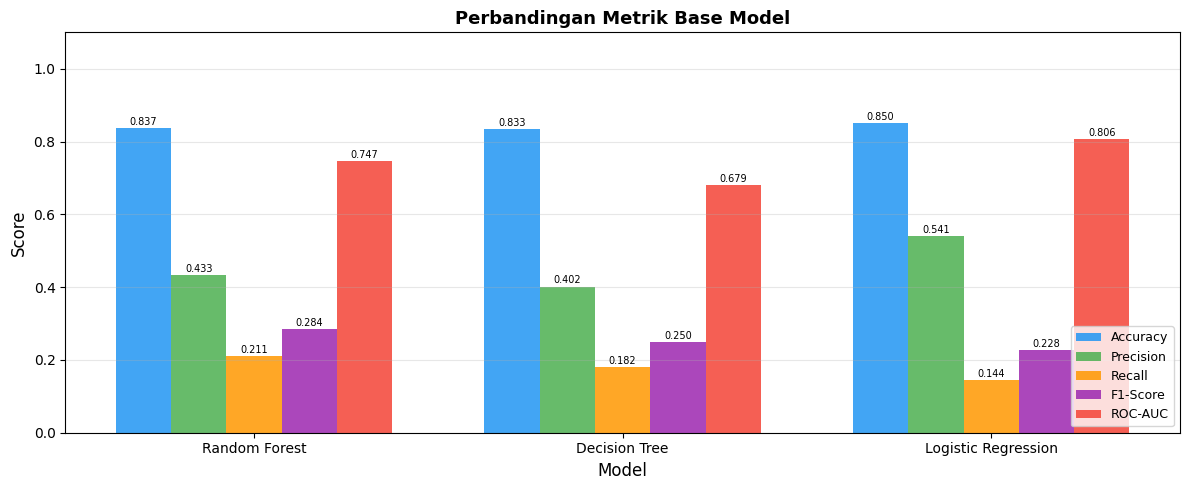

In [32]:
fig, ax = plt.subplots(figsize=(12, 5))

x       = np.arange(len(df_results))
width   = 0.15
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i*width, df_results[metric], width, label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Perbandingan Metrik Base Model', fontsize=13, fontweight='bold')
ax.set_xticks(x + width*2)
ax.set_xticklabels(df_results['Model'], fontsize=10)
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

CELL 22 — Confusion Matrix Base Model

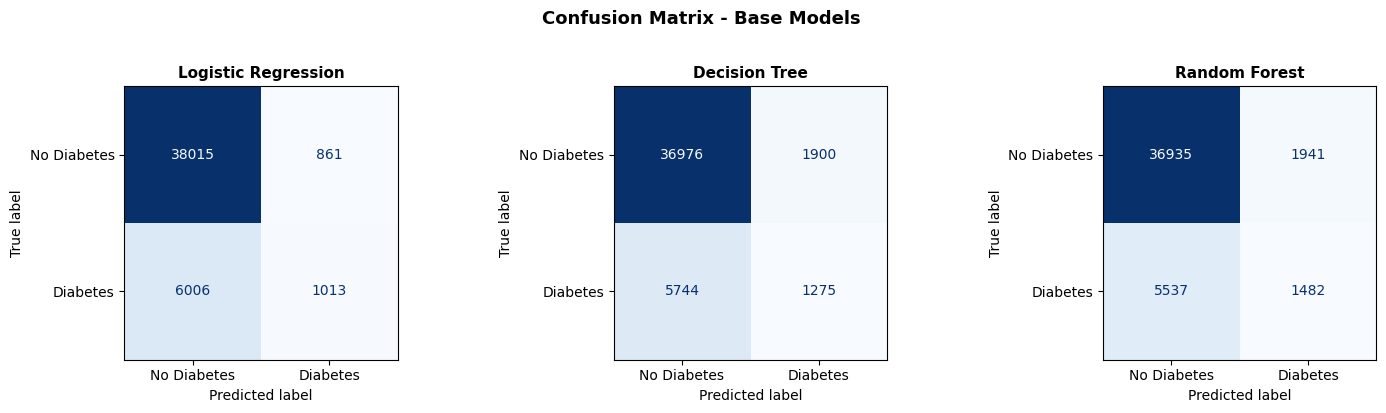

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Diabetes', 'Diabetes']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrix - Base Models', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

CELL 23 — ROC Curve Base Model

*ROC Curve menunjukkan kemampuan model membedakan kelas positif dan negatif di berbagai threshold. Semakin mendekati pojok kiri atas, semakin baik.*

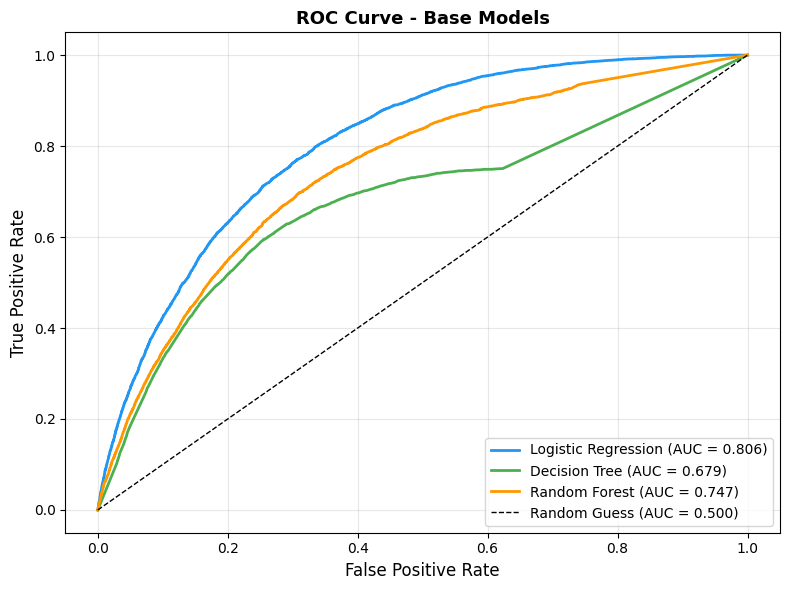

In [34]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))
colors_roc = ['#2196F3', '#4CAF50', '#FF9800']

for (name, model), color in zip(trained_models.items(), colors_roc):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess (AUC = 0.500)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Base Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

CELL 24 — Feature Importance Random Forest

*Feature importance menunjukkan fitur mana yang paling berpengaruh dalam prediksi model Random Forest.*

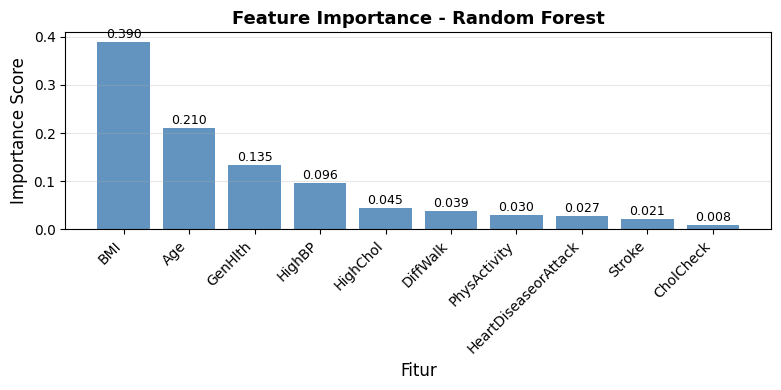


Ranking Feature Importance:
  1. BMI: 0.3899
  2. Age: 0.2096
  3. GenHlth: 0.1345
  4. HighBP: 0.0964
  5. HighChol: 0.0448
  6. DiffWalk: 0.0390
  7. PhysActivity: 0.0300
  8. HeartDiseaseorAttack: 0.0270
  9. Stroke: 0.0206
  10. CholCheck: 0.0083


In [35]:
importances = trained_models['Random Forest'].feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
bars = plt.bar(feat_imp.index, feat_imp.values, color='steelblue', alpha=0.85)
for bar, val in zip(bars, feat_imp.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.title('Feature Importance - Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Fitur', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nRanking Feature Importance:")
for i, (feat, score) in enumerate(feat_imp.items(), 1):
    print(f"  {i}. {feat}: {score:.4f}")

CELL 25 — Feature Importance Logistic Regression

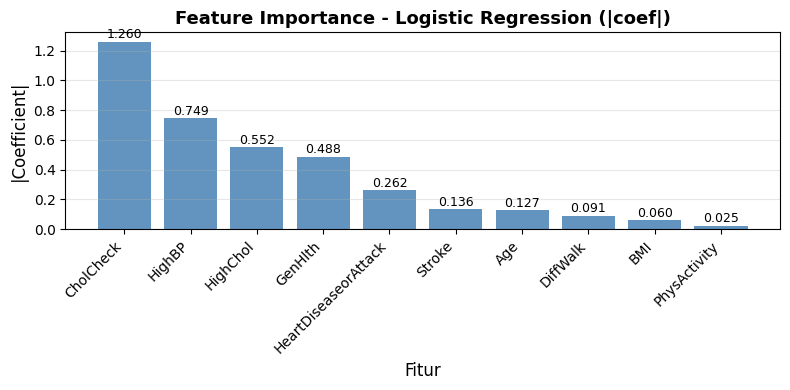


Ranking Feature Importance (Logistic Regression):
  1. CholCheck: 1.2602
  2. HighBP: 0.7486
  3. HighChol: 0.5522
  4. GenHlth: 0.4877
  5. HeartDiseaseorAttack: 0.2622
  6. Stroke: 0.1359
  7. Age: 0.1271
  8. DiffWalk: 0.0905
  9. BMI: 0.0596
  10. PhysActivity: 0.0249


In [36]:
import numpy as np

coef = trained_models['Logistic Regression'].coef_[0]
feat_imp_lr = pd.Series(np.abs(coef), index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
bars = plt.bar(feat_imp_lr.index, feat_imp_lr.values, color='steelblue', alpha=0.85)
for bar, val in zip(bars, feat_imp_lr.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.title('Feature Importance - Logistic Regression (|coef|)', fontsize=13, fontweight='bold')
plt.xlabel('Fitur', fontsize=12)
plt.ylabel('|Coefficient|', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nRanking Feature Importance (Logistic Regression):")
for i, (feat, score) in enumerate(feat_imp_lr.items(), 1):
    print(f"  {i}. {feat}: {score:.4f}")

#BAGIAN 3: OPTIMALISASI MODEL
*Tahap ini mencakup Hyperparameter Tuning, Evaluasi Model Hasil Tuning, Cross Validation, dan Perbandingan Hasil Sebelum dan Sesudah Optimalisasi.*

CELL 26 — Hyperparameter Tuning (RandomizedSearchCV)

*Optimasi dilakukan menggunakan RandomizedSearchCV dengan scoring utama Recall kelas Diabetes dan 5-Fold Stratified Cross Validation. Class weight dinaikkan hingga {0:1, 1:12} untuk memaksimalkan sensitivitas model terhadap kelas Diabetes yang minoritas.*

In [37]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, recall_score

diabetes_recall = make_scorer(recall_score, pos_label=1)

param_dist = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2'],
    'class_weight'     : [
        {0: 1, 1: 5},
        {0: 1, 1: 8},
        {0: 1, 1: 10},
        {0: 1, 1: 12},
        'balanced_subsample'
    ]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,
    scoring=diabetes_recall,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)
best_rf = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)
print("Best CV Recall :", random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'class_weight': {0: 1, 1: 10}}
Best CV Recall : 0.8848921539527062


*Parameter terbaik yang diperoleh: n_estimators: 300, min_samples_split: 10, min_samples_leaf: 4, max_features: log2, max_depth: 10, class_weight: {0:1, 1:10}, dengan Best CV Recall sebesar 0.8849.*

CELL 27 — Evaluasi Tuned Model (Default Threshold 0.5)

In [46]:
y_pred_tuned  = best_rf.predict(X_test)
y_proba_tuned = best_rf.predict_proba(X_test)[:, 1]

accuracy_tuned  = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned, pos_label=1, zero_division=0)
recall_tuned    = recall_score(y_test, y_pred_tuned, pos_label=1, zero_division=0)
f1_tuned        = f1_score(y_test, y_pred_tuned, pos_label=1, zero_division=0)
roc_auc_tuned   = roc_auc_score(y_test, y_proba_tuned)

print("--- Tuned Model (Default Threshold) ---")
print(f"Accuracy  : {accuracy_tuned:.4f}")
print(f"Precision : {precision_tuned:.4f}")
print(f"Recall    : {recall_tuned:.4f}")
print(f"F1-Score  : {f1_tuned:.4f}")
print(f"ROC-AUC   : {roc_auc_tuned:.4f}")
print("\n", classification_report(y_test, y_pred_tuned,
      target_names=['No Diabetes', 'Diabetes'], zero_division=0))

--- Tuned Model (Default Threshold) ---
Accuracy  : 0.6015
Precision : 0.2629
Recall    : 0.8903
F1-Score  : 0.4060
ROC-AUC   : 0.8121

               precision    recall  f1-score   support

 No Diabetes       0.97      0.55      0.70     38876
    Diabetes       0.26      0.89      0.41      7019

    accuracy                           0.60     45895
   macro avg       0.61      0.72      0.55     45895
weighted avg       0.86      0.60      0.66     45895



*Hasil evaluasi menunjukkan Recall kelas Diabetes mencapai 0.8903 dengan ROC-AUC 0.8121 menggunakan threshold default 0.5, sehingga threshold tuning tidak diperlukan.*

CELL 28 — Confusion Matrix & ROC Curve Tuned Model

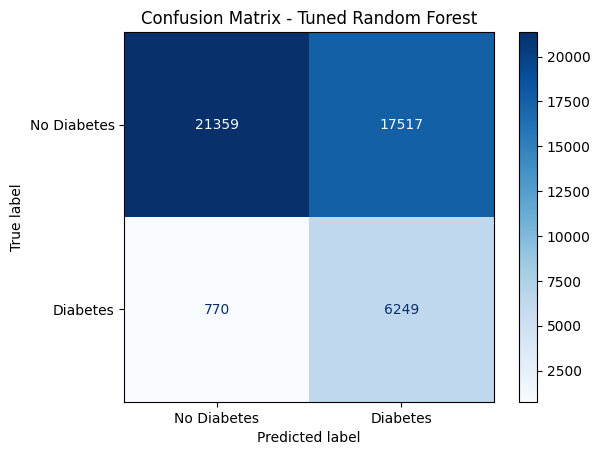

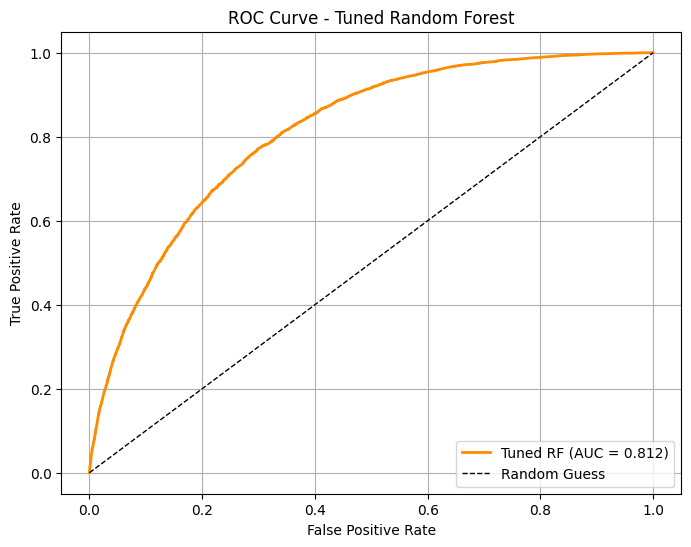

In [50]:
#Confusion Matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
ConfusionMatrixDisplay(cm_tuned, display_labels=['No Diabetes','Diabetes']).plot(cmap='Blues')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.show()

# ROC Curve
fpr_t, tpr_t, _ = roc_curve(y_test, y_proba_tuned)
auc_t = auc(fpr_t, tpr_t)

plt.figure(figsize=(8, 6))
plt.plot(fpr_t, tpr_t, color='darkorange', lw=2, label=f'Tuned RF (AUC = {auc_t:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1, label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

CELL 29 — Cross Validation

*Cross Validation dilakukan untuk mengukur kestabilan dan kemampuan generalisasi model Random Forest hasil optimasi terhadap berbagai pembagian data.*

In [51]:

from sklearn.model_selection import cross_val_score

cv_roc = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
cv_rec = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='recall', n_jobs=-1)

print("Cross Validation ROC-AUC per fold:")
for i, s in enumerate(cv_roc, 1): print(f"  Fold {i}: {s:.4f}")
print(f"  Mean: {cv_roc.mean():.4f} | Std: {cv_roc.std():.4f}")

print("\nCross Validation Recall per fold:")
for i, s in enumerate(cv_rec, 1): print(f"  Fold {i}: {s:.4f}")
print(f"  Mean: {cv_rec.mean():.4f} | Std: {cv_rec.std():.4f}")

Cross Validation ROC-AUC per fold:
  Fold 1: 0.8089
  Fold 2: 0.8074
  Fold 3: 0.8036
  Fold 4: 0.8112
  Fold 5: 0.8068
  Mean: 0.8076 | Std: 0.0025

Cross Validation Recall per fold:
  Fold 1: 0.8873
  Fold 2: 0.8837
  Fold 3: 0.8782
  Fold 4: 0.8882
  Fold 5: 0.8841
  Mean: 0.8843 | Std: 0.0035


CELL 30 — Perbandingan Base vs Optimized

   Metric  Base Random Forest  Optimized Random Forest
 Accuracy              0.8371                 0.601547
Precision              0.4330                 0.262939
   Recall              0.2111                 0.890298
 F1-Score              0.2839                 0.405977
  ROC-AUC              0.7466                 0.812088


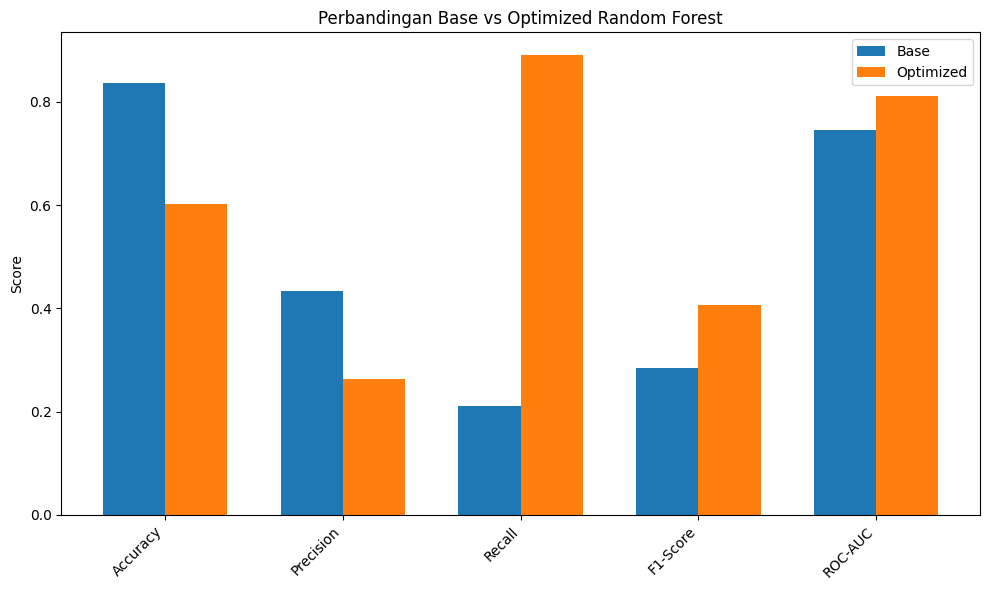

In [54]:

base_rf = df_results[df_results['Model'] == 'Random Forest'].iloc[0]

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Base Random Forest': [
        base_rf['Accuracy'], base_rf['Precision'],
        base_rf['Recall'], base_rf['F1-Score'], base_rf['ROC-AUC']
    ],
    'Optimized Random Forest': [
        accuracy_score(y_test, y_pred_tuned),       # <-- ganti y_pred_final → y_pred_tuned
        precision_score(y_test, y_pred_tuned, zero_division=0),
        recall_score(y_test, y_pred_tuned, zero_division=0),
        f1_score(y_test, y_pred_tuned, zero_division=0),
        roc_auc_score(y_test, y_proba_tuned)
    ]
})
print(comparison.to_string(index=False))

x = np.arange(len(comparison))
width = 0.35
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, comparison['Base Random Forest'], width, label='Base')
plt.bar(x + width/2, comparison['Optimized Random Forest'], width, label='Optimized')
plt.xticks(x, comparison['Metric'], rotation=45, ha='right')
plt.ylabel('Score')
plt.title('Perbandingan Base vs Optimized Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

CELL 31 — Test Prediksi Manual

In [57]:
import joblib
import pandas as pd

model_loaded = joblib.load('diabetes_rf_model.pkl')

# Urutan harus sama persis dengan X.columns saat training
print("Urutan fitur saat training:", model_loaded.feature_names_in_)

data_baru = pd.DataFrame({
    'HighBP'              : [1],
    'HighChol'            : [1],
    'CholCheck'           : [1],
    'BMI'                 : [35],
    'PhysActivity'        : [0],
    'GenHlth'             : [3],
    'Age'                 : [9],
    'DiffWalk'            : [1],
    'HeartDiseaseorAttack': [0],
    'Stroke'              : [0]
})[model_loaded.feature_names_in_]  # <-- reorder otomatis sesuai training

proba = model_loaded.predict_proba(data_baru)[:, 1][0]
hasil = int(proba >= 0.5)  # pakai default threshold 0.5

print(f"Probabilitas Diabetes : {proba:.4f}")
print(f"Hasil Prediksi        : {'🔴 Berisiko Diabetes' if hasil == 1 else '🟢 Tidak Berisiko Diabetes'}")

Urutan fitur saat training: ['HighBP' 'HighChol' 'CholCheck' 'BMI' 'Stroke' 'HeartDiseaseorAttack'
 'PhysActivity' 'GenHlth' 'DiffWalk' 'Age']
Probabilitas Diabetes : 0.8825
Hasil Prediksi        : 🔴 Berisiko Diabetes


**Model Final: Random Forest dengan parameter n_estimators=300, max_depth=10, min_samples_leaf=4, min_samples_split=10, max_features=log2, class_weight={0:1, 1:10}, threshold default 0.5.**

In [59]:
import os
import matplotlib
matplotlib.use('Agg')  # non-interactive backend
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)
from google.colab import files

os.makedirs('outputs', exist_ok=True)

# ── 1. Distribusi Target ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=y, ax=ax)
ax.set_title('Distribution of Diabetes_binary (Target Class)')
ax.set_xlabel('Diabetes_binary')
ax.set_ylabel('Count')
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Diabetes', 'Diabetes'])
fig.savefig('outputs/01_distribusi_target.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# ── 2. Correlation Heatmap ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
df_full = pd.concat([X, y], axis=1)
sns.heatmap(df_full.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=ax)
ax.set_title('Correlation Matrix of Features')
fig.savefig('outputs/02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# ── 3. Mutual Information ─────────────────────────────────────────
from sklearn.feature_selection import mutual_info_classif
mi_scores = mutual_info_classif(X, y.values.ravel(), random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
mi_series.plot(kind='bar', ax=ax)
ax.set_title('Mutual Information Scores of Features with Diabetes_binary')
ax.set_xlabel('Features')
ax.set_ylabel('Mutual Information Score')
plt.xticks(rotation=90)
fig.savefig('outputs/03_mutual_information.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# ── 4. Perbandingan Metrik Base Model ─────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x       = np.arange(len(df_results))
width   = 0.15
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i*width, df_results[metric], width, label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Perbandingan Metrik Base Model - CDC Diabetes Classification', fontsize=13, fontweight='bold')
ax.set_xticks(x + width*2)
ax.set_xticklabels(df_results['Model'], fontsize=10)
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
fig.savefig('outputs/04_metrik_base_model.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# ── 5. Confusion Matrix Base Model ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Diabetes', 'Diabetes']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontweight='bold', fontsize=11)
plt.suptitle('Confusion Matrix - Base Models', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig('outputs/05_confusion_matrix_base.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# ── 6. ROC Curve Base Model ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#2196F3', '#4CAF50', '#FF9800']
for (name, model), color in zip(trained_models.items(), colors_roc):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - Base Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
fig.savefig('outputs/06_roc_curve_base.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# ── 7. Feature Importance Random Forest ──────────────────────────
importances = trained_models['Random Forest'].feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(feat_imp.index, feat_imp.values, color='steelblue', alpha=0.85)
for bar, val in zip(bars, feat_imp.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Feature Importance - Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Fitur', fontsize=12)
ax.set_ylabel('Importance Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
fig.savefig('outputs/07_feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# ── 8. Feature Importance Logistic Regression ────────────────────
coef = trained_models['Logistic Regression'].coef_[0]
feat_imp_lr = pd.Series(np.abs(coef), index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(feat_imp_lr.index, feat_imp_lr.values, color='steelblue', alpha=0.85)
for bar, val in zip(bars, feat_imp_lr.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Feature Importance - Logistic Regression (|coef|)', fontsize=13, fontweight='bold')
ax.set_xlabel('Fitur', fontsize=12)
ax.set_ylabel('|Coefficient|', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
fig.savefig('outputs/08_feature_importance_lr.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# ── 9. Confusion Matrix Tuned Model ──────────────────────────────
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_tuned, display_labels=['No Diabetes','Diabetes']).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix - Tuned Random Forest', fontweight='bold')
fig.savefig('outputs/09_confusion_matrix_tuned.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# ── 10. ROC Curve Tuned Model ─────────────────────────────────────
fpr_t, tpr_t, _ = roc_curve(y_test, y_proba_tuned)
auc_t = auc(fpr_t, tpr_t)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_t, tpr_t, color='darkorange', lw=2, label=f'Tuned RF (AUC = {auc_t:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Tuned Random Forest')
ax.legend(loc='lower right')
ax.grid(True)
fig.savefig('outputs/10_roc_curve_tuned.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# ── 11. Perbandingan Base vs Optimized ───────────────────────────
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Base Random Forest': [
        base_rf['Accuracy'], base_rf['Precision'],
        base_rf['Recall'], base_rf['F1-Score'], base_rf['ROC-AUC']
    ],
    'Optimized Random Forest': [
        accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned, zero_division=0),
        recall_score(y_test, y_pred_tuned, zero_division=0),
        f1_score(y_test, y_pred_tuned, zero_division=0),
        roc_auc_score(y_test, y_proba_tuned)
    ]
})
x = np.arange(len(comparison))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, comparison['Base Random Forest'], width, label='Base Random Forest')
ax.bar(x + width/2, comparison['Optimized Random Forest'], width, label='Optimized Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Metric'], rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('Perbandingan Base vs Optimized Random Forest')
ax.legend()
fig.savefig('outputs/11_perbandingan_base_optimized.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# ── 12. Simpan Model PKL ─────────────────────────────────────────
import joblib
joblib.dump(best_rf, 'outputs/diabetes_rf_model.pkl')

# ── ZIP & Download Semua ─────────────────────────────────────────
import shutil
shutil.make_archive('diabetes_outputs', 'zip', 'outputs')
files.download('diabetes_outputs.zip')

print("✅ Semua file berhasil disimpan dan didownload!")
print("\nIsi file ZIP:")
for f in sorted(os.listdir('outputs')):
    print(f"  - {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Semua file berhasil disimpan dan didownload!

Isi file ZIP:
  - 01_distribusi_target.png
  - 02_correlation_heatmap.png
  - 03_mutual_information.png
  - 04_metrik_base_model.png
  - 05_confusion_matrix_base.png
  - 06_roc_curve_base.png
  - 07_feature_importance_rf.png
  - 08_feature_importance_lr.png
  - 09_confusion_matrix_tuned.png
  - 10_roc_curve_tuned.png
  - 11_perbandingan_base_optimized.png
  - diabetes_rf_model.pkl
